In [19]:
%matplotlib inline
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

In [20]:
# building a perfect quantum circuit
qc = QuantumCircuit(2,2)
qc.h(0)
qc.cx(0,1)
qc.measure([0,1],[0,1])

simulator = AerSimulator()
compiled_circuit = transpile(qc, simulator)

In [21]:
noise_levels = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0] # noise levels from 0% to 100% 

In [22]:
probabilities = []  # this empty list will store the final grades (survival percentage)
correlations = []

In [23]:
for noise in noise_levels:
    noise_model = NoiseModel()
    noise_model.add_all_qubit_quantum_error(depolarizing_error(noise,1),['h'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(noise,2),['cx'])

    sim_noisy = AerSimulator(noise_model=noise_model)
    job = sim_noisy.run(compiled_circuit, shots=1024)
    result = job.result()
    counts = result.get_counts()

    #calculating how many perfect quantum keys survived 
    matches = counts.get('00',0) + counts.get('11',0)
    prob_matches = matches / 1024
    # calculating the error
    errors = counts.get('01',0) + counts.get('10',0)
    prob_errors = errors / 1024

    #saving the metrics
    probabilities.append(prob_matches)
    correlations.append(prob_matches - prob_errors)  #the correlation formula

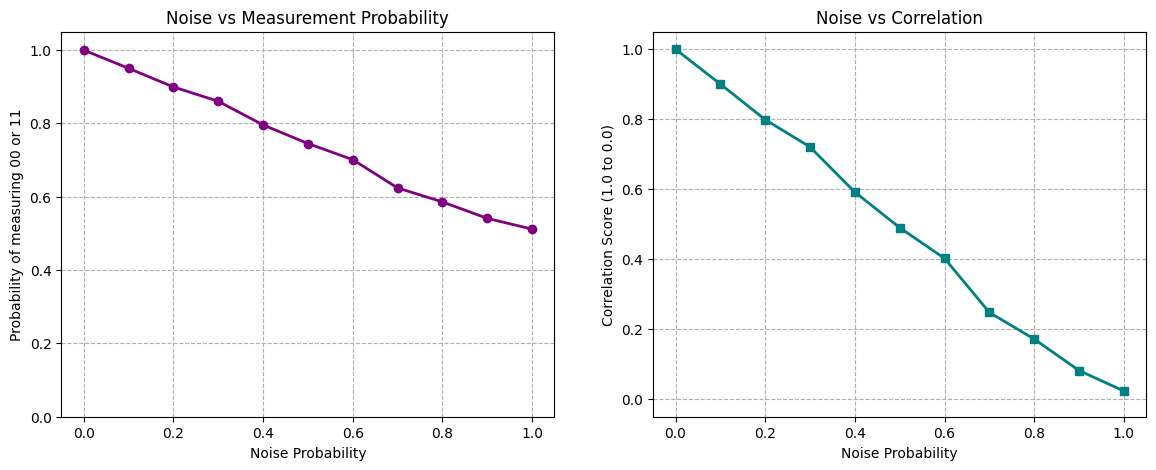

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Graph A: Noise vs Measurement Probability
ax1.plot(noise_levels, probabilities, marker='o', color='purple', linewidth=2)
ax1.set_title('Noise vs Measurement Probability')
ax1.set_xlabel('Noise Probability')
ax1.set_ylabel('Probability of measuring 00 or 11')
ax1.grid(True, linestyle='--')
ax1.set_ylim(0, 1.05)

# Graph B: Noise vs Correlation
ax2.plot(noise_levels, correlations, marker='s', color='teal', linewidth=2)
ax2.set_title('Noise vs Correlation')
ax2.set_xlabel('Noise Probability')
ax2.set_ylabel('Correlation Score (1.0 to 0.0)')
ax2.grid(True, linestyle='--')
ax2.set_ylim(-0.05, 1.05)

plt.show()